<a href="https://colab.research.google.com/github/jiki007/OS_project/blob/main/PackageManager.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib networkx

import random
import datetime
import time
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

In [ ]:
# Simulated package repository (like Ubuntu's apt repository)
repository = {
    "nginx": {"version": "1.24.0", "size": 850, "dependencies": ["openssl", "zlib"]},
    "openssl": {"version": "3.1.0", "size": 1200, "dependencies": ["zlib"]},
    "zlib": {"version": "1.2.13", "size": 200, "dependencies": []},
    "python3": {"version": "3.11.0", "size": 4500, "dependencies": ["zlib", "openssl"]},
    "pip": {"version": "23.0", "size": 300, "dependencies": ["python3"]},
    "curl": {"version": "8.1.0", "size": 500, "dependencies": ["openssl", "zlib"]},
    "git": {"version": "2.41.0", "size": 1800, "dependencies": ["openssl", "curl"]},
    "vim": {"version": "9.0", "size": 700, "dependencies": []},
    "docker": {"version": "24.0.0", "size": 8000, "dependencies": ["python3", "git", "curl"]},
    "nodejs": {"version": "18.17.0", "size": 3500, "dependencies": ["openssl", "zlib"]},
    "npm": {"version": "9.8.0", "size": 600, "dependencies": ["nodejs"]},
    "mysql": {"version": "8.1.0", "size": 5000, "dependencies": ["openssl", "zlib"]},
    "apache2": {"version": "2.4.57", "size": 1100, "dependencies": ["openssl", "zlib"]},
    "ffmpeg": {"version": "6.0", "size": 7000, "dependencies": ["zlib", "openssl"]},
    "wget": {"version": "1.21.4", "size": 400, "dependencies": ["openssl", "zlib"]},
}

# Installed packages tracker
installed_packages = {}

# Operation log
operation_log = []

print(f"✅ Repository loaded with {len(repository)} packages")
print(f"\n{'Package':<15} {'Version':<12} {'Size (KB)':<12} Dependencies")
print("-" * 60)
for pkg, info in repository.items():
    print(f"{pkg:<15} {info['version']:<12} {info['size']:<12} {', '.join(info['dependencies']) or 'None'}")

✅ Repository loaded with 15 packages

Package         Version      Size (KB)    Dependencies
------------------------------------------------------------
nginx           1.24.0       850          openssl, zlib
openssl         3.1.0        1200         zlib
zlib            1.2.13       200          None
python3         3.11.0       4500         zlib, openssl
pip             23.0         300          python3
curl            8.1.0        500          openssl, zlib
git             2.41.0       1800         openssl, curl
vim             9.0          700          None
docker          24.0.0       8000         python3, git, curl
nodejs          18.17.0      3500         openssl, zlib
npm             9.8.0        600          nodejs
mysql           8.1.0        5000         openssl, zlib
apache2         2.4.57       1100         openssl, zlib
ffmpeg          6.0          7000         zlib, openssl
wget            1.21.4       400          openssl, zlib


In [ ]:
def log_operation(action, package, status, details=""):
    operation_log.append({
        "time": datetime.datetime.now().strftime("%H:%M:%S"),
        "action": action,
        "package": package,
        "status": status,
        "details": details
    })

def get_all_dependencies(package, resolved=None):
    """Recursively resolve all dependencies"""
    if resolved is None:
        resolved = []
    if package not in repository:
        return resolved
    for dep in repository[package]["dependencies"]:
        if dep not in resolved:
            resolved.append(dep)
            get_all_dependencies(dep, resolved)
    return resolved

def install_package(package):
    print(f"\n📦 Installing: {package}")
    print("-" * 40)

    if package not in repository:
        print(f"  ❌ Error: '{package}' not found in repository")
        log_operation("INSTALL", package, "FAILED", "Package not found")
        return

    if package in installed_packages:
        print(f"  ℹ️ '{package}' is already installed (v{installed_packages[package]['version']})")
        log_operation("INSTALL", package, "SKIPPED", "Already installed")
        return

    # Resolve dependencies
    deps = get_all_dependencies(package)
    if deps:
        print(f"  🔍 Resolving dependencies: {', '.join(deps)}")
        for dep in deps:
            if dep not in installed_packages:
                print(f"  ⬇️  Installing dependency: {dep} v{repository[dep]['version']}")
                time.sleep(0.3)
                installed_packages[dep] = repository[dep]
                log_operation("INSTALL", dep, "SUCCESS", f"Dependency of {package}")

    # Install main package
    print(f"  ⬇️  Installing: {package} v{repository[package]['version']}")
    time.sleep(0.5)
    installed_packages[package] = repository[package]
    log_operation("INSTALL", package, "SUCCESS", f"Size: {repository[package]['size']} KB")
    print(f"  ✅ Successfully installed {package} v{repository[package]['version']}")

def remove_package(package):
    print(f"\n🗑️  Removing: {package}")
    print("-" * 40)

    if package not in installed_packages:
        print(f"  ❌ '{package}' is not installed")
        log_operation("REMOVE", package, "FAILED", "Not installed")
        return

    # Check if other packages depend on this
    dependents = [
        pkg for pkg, info in installed_packages.items()
        if package in info["dependencies"] and pkg != package
    ]

    if dependents:
        print(f"  ⚠️  Warning: {', '.join(dependents)} depend on {package}")
        print(f"  🗑️  Removing anyway (simulated force remove)...")

    del installed_packages[package]
    log_operation("REMOVE", package, "SUCCESS", f"Dependents: {', '.join(dependents) or 'None'}")
    print(f"  ✅ Successfully removed {package}")

def update_package(package):
    print(f"\n🔄 Updating: {package}")
    print("-" * 40)

    if package not in installed_packages:
        print(f"  ❌ '{package}' is not installed. Installing instead...")
        install_package(package)
        return

    old_version = installed_packages[package]["version"]
    # Simulate version bump
    version_parts = old_version.split(".")
    version_parts[-1] = str(int(version_parts[-1]) + 1)
    new_version = ".".join(version_parts)

    installed_packages[package]["version"] = new_version
    log_operation("UPDATE", package, "SUCCESS", f"v{old_version} → v{new_version}")
    print(f"  ✅ Updated {package}: v{old_version} → v{new_version}")

def list_installed():
    if not installed_packages:
        print("No packages installed yet.")
        return
    print(f"\n{'Package':<15} {'Version':<12} {'Size (KB)':<12} Dependencies")
    print("-" * 60)
    for pkg, info in installed_packages.items():
        print(f"{pkg:<15} {info['version']:<12} {info['size']:<12} {', '.join(info['dependencies']) or 'None'}")
    total_size = sum(info["size"] for info in installed_packages.values())
    print(f"\n  Total packages : {len(installed_packages)}")
    print(f"  Total size     : {total_size} KB ({round(total_size/1024, 2)} MB)")

In [ ]:
# Simulate a series of package operations
print("=" * 50)
print("  Ubuntu Package Manager Simulator (apt)")
print("=" * 50)

# Install packages
install_package("docker")
install_package("mysql")
install_package("vim")
install_package("npm")

# Try installing already installed
install_package("git")

# Update some packages
update_package("nginx")
update_package("vim")

# Remove a package
remove_package("vim")

# Try removing non-existent
remove_package("apache2")

# List all installed
print("\n📋 Currently Installed Packages:")
list_installed()

  Ubuntu Package Manager Simulator (apt)

📦 Installing: docker
----------------------------------------
  🔍 Resolving dependencies: python3, zlib, openssl, git, curl
  ⬇️  Installing dependency: python3 v3.11.0
  ⬇️  Installing dependency: zlib v1.2.13
  ⬇️  Installing dependency: openssl v3.1.0
  ⬇️  Installing dependency: git v2.41.0
  ⬇️  Installing dependency: curl v8.1.0
  ⬇️  Installing: docker v24.0.0
  ✅ Successfully installed docker v24.0.0

📦 Installing: mysql
----------------------------------------
  🔍 Resolving dependencies: openssl, zlib
  ⬇️  Installing: mysql v8.1.0
  ✅ Successfully installed mysql v8.1.0

📦 Installing: vim
----------------------------------------
  ⬇️  Installing: vim v9.0
  ✅ Successfully installed vim v9.0

📦 Installing: npm
----------------------------------------
  🔍 Resolving dependencies: nodejs, openssl, zlib
  ⬇️  Installing dependency: nodejs v18.17.0
  ⬇️  Installing: npm v9.8.0
  ✅ Successfully installed npm v9.8.0

📦 Installing: git
-------

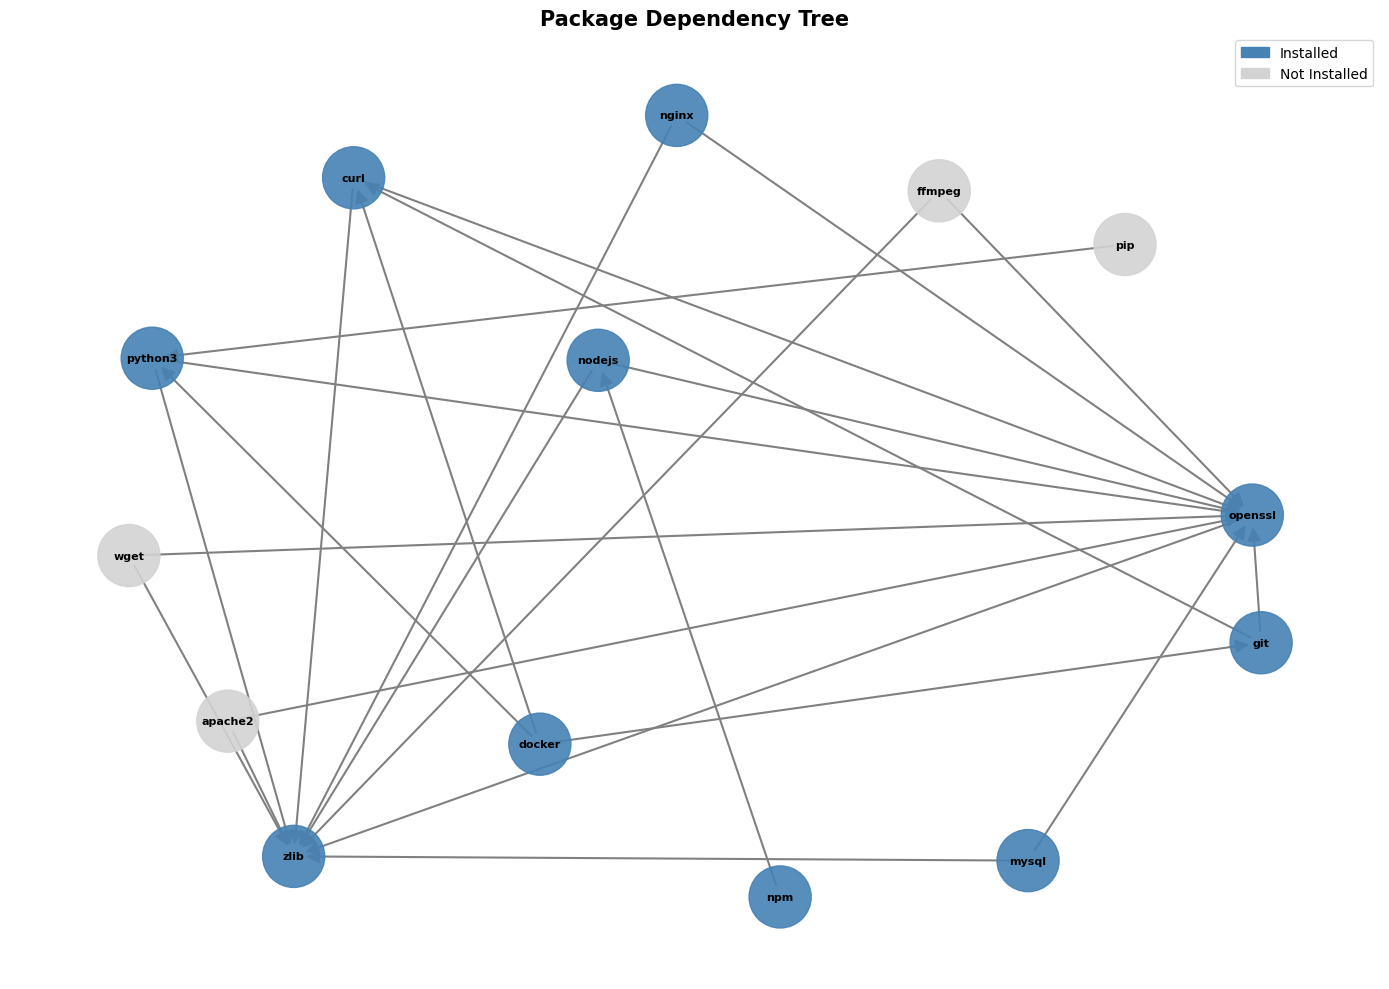

In [ ]:
def visualize_dependency_tree():
    G = nx.DiGraph()

    for pkg, info in repository.items():
        for dep in info["dependencies"]:
            G.add_edge(pkg, dep)

    # Color installed vs not installed
    node_colors = []
    for node in G.nodes():
        if node in installed_packages:
            node_colors.append("steelblue")
        else:
            node_colors.append("lightgray")

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                           arrowsize=20, width=1.5)

    import matplotlib.patches as mpatches
    installed_patch = mpatches.Patch(color="steelblue", label="Installed")
    not_installed_patch = mpatches.Patch(color="lightgray", label="Not Installed")
    plt.legend(handles=[installed_patch, not_installed_patch], fontsize=10)

    plt.title("Package Dependency Tree", fontsize=15, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_dependency_tree()

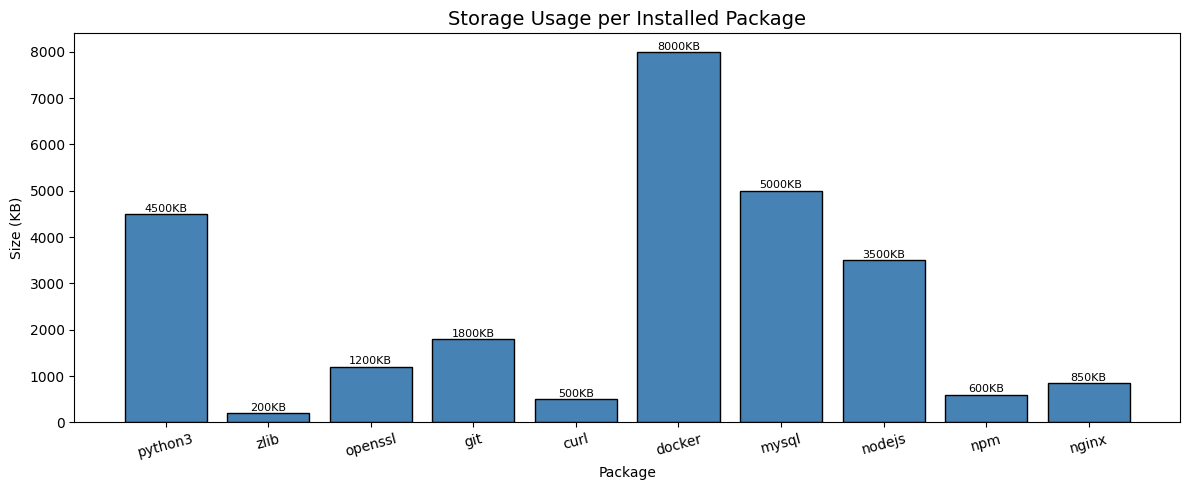

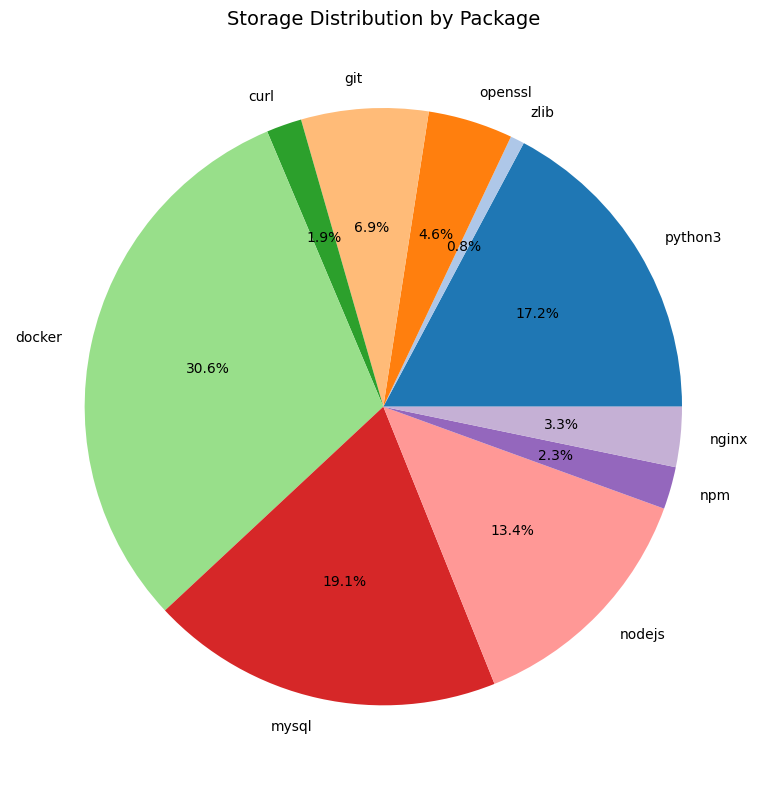

In [ ]:
def visualize_storage():
    if not installed_packages:
        print("No packages installed.")
        return

    packages = list(installed_packages.keys())
    sizes = [installed_packages[p]["size"] for p in packages]

    # Bar chart
    plt.figure(figsize=(12, 5))
    bars = plt.bar(packages, sizes, color="steelblue", edgecolor="black")
    plt.title("Storage Usage per Installed Package", fontsize=14)
    plt.xlabel("Package")
    plt.ylabel("Size (KB)")
    plt.xticks(rotation=15)

    # Add size labels on bars
    for bar, size in zip(bars, sizes):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f"{size}KB", ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=packages, autopct="%1.1f%%",
            colors=plt.cm.tab20.colors)
    plt.title("Storage Distribution by Package", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_storage()

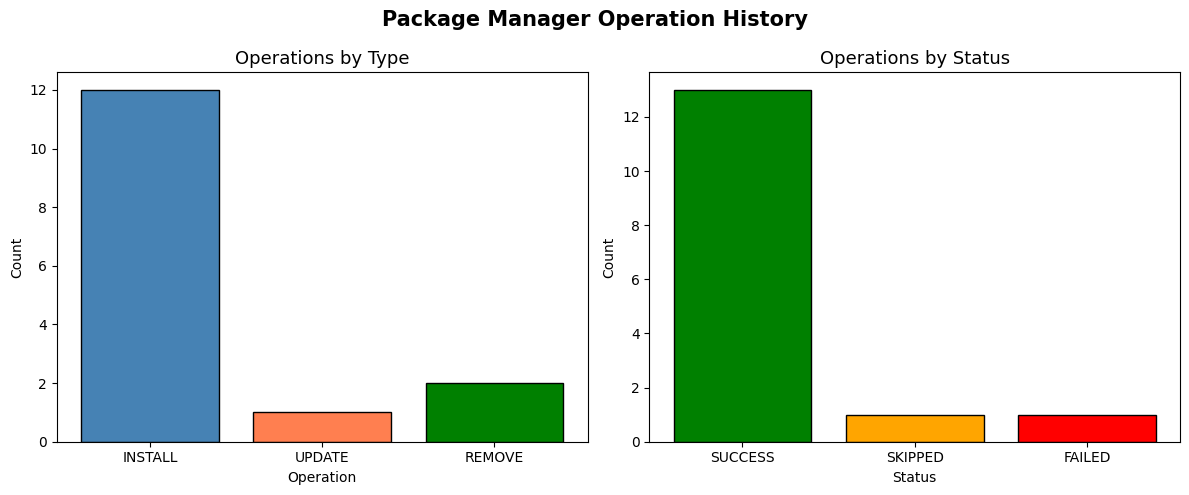

In [ ]:
def visualize_operations():
    from collections import Counter

    actions = Counter(e["action"] for e in operation_log)
    statuses = Counter(e["status"] for e in operation_log)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Operations by type
    axes[0].bar(actions.keys(), actions.values(),
                color=["steelblue", "coral", "green"], edgecolor="black")
    axes[0].set_title("Operations by Type", fontsize=13)
    axes[0].set_xlabel("Operation")
    axes[0].set_ylabel("Count")

    # Operations by status
    status_colors = {"SUCCESS": "green", "FAILED": "red", "SKIPPED": "orange"}
    colors = [status_colors.get(s, "gray") for s in statuses.keys()]
    axes[1].bar(statuses.keys(), statuses.values(),
                color=colors, edgecolor="black")
    axes[1].set_title("Operations by Status", fontsize=13)
    axes[1].set_xlabel("Status")
    axes[1].set_ylabel("Count")

    plt.suptitle("Package Manager Operation History", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

visualize_operations()

In [ ]:
print(f"\n{'Time':<12} {'Action':<10} {'Package':<15} {'Status':<10} Details")
print("-" * 70)
for entry in operation_log:
    print(f"{entry['time']:<12} {entry['action']:<10} "
          f"{entry['package']:<15} {entry['status']:<10} {entry['details']}")


Time         Action     Package         Status     Details
----------------------------------------------------------------------
01:07:04     INSTALL    python3         SUCCESS    Dependency of docker
01:07:04     INSTALL    zlib            SUCCESS    Dependency of docker
01:07:04     INSTALL    openssl         SUCCESS    Dependency of docker
01:07:05     INSTALL    git             SUCCESS    Dependency of docker
01:07:05     INSTALL    curl            SUCCESS    Dependency of docker
01:07:05     INSTALL    docker          SUCCESS    Size: 8000 KB
01:07:06     INSTALL    mysql           SUCCESS    Size: 5000 KB
01:07:06     INSTALL    vim             SUCCESS    Size: 700 KB
01:07:07     INSTALL    nodejs          SUCCESS    Dependency of npm
01:07:07     INSTALL    npm             SUCCESS    Size: 600 KB
01:07:07     INSTALL    git             SKIPPED    Already installed
01:07:08     INSTALL    nginx           SUCCESS    Size: 850 KB
01:07:08     UPDATE     vim             SUCCESS  